--file not found. Please enter the correct filepath.

--- Data Cleaning Complete ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64


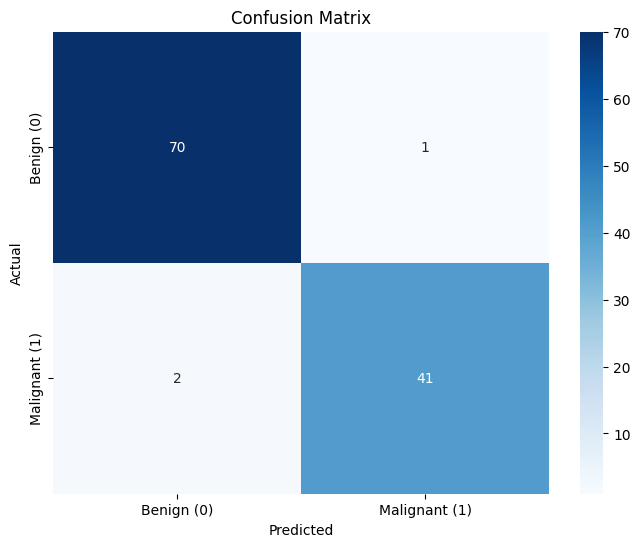

In [7]:
# --- Import Dependencies ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, precision_score, roc_auc_score, f1_score

# Load the dataset (Breast Cancer Wisconsin)
try:
    df = pd.read_csv("data.csv")
    print("--successfully loaded dataset...")
except FileNotFoundError:
    print("--file not found. Please enter the correct filepath.")
    exit()

# --- 1. Data Cleaning and Target Encoding ---

# Drop unnecessary and corrupt columns
# 'id' is a redundant identifier; 'Unnamed: 32' is full of nulls/garbage data.
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)

# Encode the target variable 'diagnosis' (M=Malignant/1, B=Benign/0)
# This is mandatory for classification models.
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print("\n--- Data Cleaning Complete ---")
print(df.info())

# --- 2. Define X (Features) and Y (Target) ---

Y = df['diagnosis']
X = df.drop('diagnosis', axis=1)

# --- 3. Train-Test Split ---

# Split the data into 80% training and 20% testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# --- 4. Feature Scaling (Standardization) ---

# RATIONALE: Standardization is mandatory for Logistic Regression (which uses Gradient Descent) 
# to ensure fast convergence and comparable coefficients.
scaler = StandardScaler()

# Fit scaler ONLY on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train) 

# Transform both test and train sets
X_test_scaled = scaler.transform(X_test) 

# --- 5. Model Training and Prediction ---

log_model = LogisticRegression(solver='liblinear', random_state=42)
log_model.fit(X_train_scaled, y_train)

# Predict probabilities for ROC-AUC
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# Predict classes for Confusion Matrix/Precision/Recall
y_pred = log_model.predict(X_test_scaled) 
print("\n--- Model Training Complete ---")

# --- 6. Model Evaluation and Metrics ---

# a) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# b) Key Classification Metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) # Uses probabilities (y_prob)

print(f"\nPrecision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Visualize Confusion Matrix (Optional but Recommended)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()